# NB09c: Stacking + LightGBM + NaN Ablation + Classical ML v3 (with NB12 OOF predictions schema)Manifest-driven v2 parquet loading. Per-cell load + del + gc.Main feature set is `fusion_composite_blockstats` F8 ("all_multimodal") —the v2 equivalent of v1 `bda_product_prepost`. Modality subsets (card_only,coh_only, ms_only, card+coh) are derived from F8's column namespace, notseparate parquet loads — this matches the v1 behavior of slicing columnsfrom a single wide table.Experiments:- E1: stacking meta-learner (LogReg on base model OOF)- E2: LightGBM + sensor ablation- E5: LightGBM / HistGBM native NaN (MIA leakage risk)- E6: NaN ablation (A impute+flags, B native NaN, C SAR-only) + SHAP leakage check- E7: SVM + KNN + LogReg- E7b: GaussianNB + LDA/QDA + Ridge + NearestCentroid- E7c: HistGBM + CatBoost + ExtraTrees + BalancedRF- E7d: MLP- E8: IsolationForest (unsupervised anomaly)- E9: comparison table- E10: save OOF predictions

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


# CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB09c CONFIG + GLOBAL SETUP
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-06-14 17:59:29
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     930.0/7452.0 GB (6522.0 GB free)
  GDrive (F:)     1406.2/3726.0 GB (2319.8 GB free)
  Local data      11563.0/14901.9 GB (3338.9 GB free)
  Data stack      1406.2/3726.0 GB (2319.8 GB free)
  WSL ext4        69.1/1006.9 GB (886.5 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: MANIFEST + BUILDINGS + SHARED HELPERSLoads v2 parquet manifest, building metadata, defines `load_v2(manifest_key)`.Main feature parquet is `fusion_composite_blockstats` F8 (all_multimodal).Modality subsets derived from F8 column namespace via regex.

In [2]:
# @title CELL S0: NB09c v2 MANIFEST + BUILDINGS + SHARED HELPERS
import sys, importlib, re, time, gc, json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, IsolationForest)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

print("=" * 70)
print("CELL S0: NB09c v2 - MANIFEST + BUILDINGS + HELPERS")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# --- load v2 manifest -------------------------------------------------
MANIFEST_V2_PATH = DATASET_ROOT_V2 / 'parquet_manifest.json'
if not MANIFEST_V2_PATH.exists():
    raise FileNotFoundError(f"V2 manifest not found: {MANIFEST_V2_PATH}")
with open(MANIFEST_V2_PATH) as _f:
    MANIFEST = json.load(_f)
print(f"  Manifest: {MANIFEST_V2_PATH}")
print(f"  Parquets: {len(MANIFEST['parquets'])}")

# --- load building metadata (v2 path) --------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
_bldg_pattern = str(DATASET_ROOT_V2 / 'bda_buildings_t{tier}.parquet')
df_bldg = load_tier_parquets(_bldg_pattern, _tiers)

CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)
df_bldg = df_bldg[df_bldg['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
print(f"  Cities: {len(CITIES_TO_PROCESS)}")
print(f"  Buildings: {len(df_bldg)} (damaged={int((df_bldg['damage_binary']==1).sum())}, undamaged={int((df_bldg['damage_binary']==0).sum())})")

TARGET_COL = 'damage_binary'
N_FOLDS = 5
EXPERIMENT_LOG = {}

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
from scipy.stats import rankdata as _rankdata
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09c_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

OOF_DIR = (RESULTS_ROOT / 'nb09c_v2' / 'oof_predictions')
OOF_DIR.mkdir(parents=True, exist_ok=True)

def save_oof_from_result(res, model_id, variant_id='',
                         is_final=False, threshold=0.5):
    '''Supervised: canonical OOF from a result dict.'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'building_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys")
        return None
    y_proba = np.asarray(res['y_proba'])
    yt = np.asarray(res['y_true']).astype(int)
    fold = np.asarray(res['fold_id']).astype(int)
    bid = np.asarray(res['building_id'])
    cty = np.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

def save_oof_unsupervised(building_ids, cities, y_true, scores, model_id,
                          variant_id='', threshold=0.5):
    '''Unsupervised: rank-normalize raw scores to [0,1], threshold at median; fold_id=0.'''
    scores = np.asarray(scores, dtype=float)
    valid = ~np.isnan(scores)
    if valid.sum() == 0:
        print(f"    [save_oof_unsup] skipped {model_id}: no valid scores")
        return None
    s = scores[valid]
    yt = np.asarray(y_true).astype(int)[valid]
    bid = np.asarray(building_ids)[valid]
    cty = np.asarray(cities)[valid]
    y_proba = _rankdata(s) / len(s)
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       np.zeros(len(yt), dtype=int),
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      False,
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# --- metadata filter: single source of truth for leakage exclusion ----
# Previous hardcoded LEAKAGE_EXCLUDE_PATTERNS (4 patterns) covered only a
# subset of leakage vectors -- missing was_observed_*, s1__vv__scenes_observed,
# s2__scenes_observed, s2__lu__scenes_observed, s2__visibility__{fire,smoke,
# clear}__freq, block __count_*, and rolling __count_*. metadata_filter.
# is_non_feature() catches all of them. Note: this filter runs on manifest
# columns BEFORE prepare_Xy_from()'s add_was_observed=True path constructs
# was_obs__{col} flags from NaN patterns -- that deliberate-leakage ablation
# is unaffected (different naming: was_obs__ with double underscore vs. the
# manifest was_observed_ pattern).
import importlib
import metadata_filter
importlib.reload(metadata_filter)
from metadata_filter import is_non_feature

def drop_leakage(cols):
    # Thin wrapper so existing load_v2() and prepare_Xy_from() keep working.
    # Strictly MORE restrictive than the old 4-pattern filter.
    return [c for c in cols if not is_non_feature(c)]


# --- v2 manifest-driven loader (same pattern as NB09a/NB09b v2) -----
def load_v2(manifest_key, tiers=None, columns=None, sample_frac=None):
    '''Load a v2 parquet by manifest key, merge with buildings, return df.'''
    if manifest_key not in MANIFEST['parquets']:
        raise KeyError(f"Manifest key not found: {manifest_key}")
    info = MANIFEST['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers

    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V2 / fname_tmpl.format(tier=t)
        if not pf.exists():
            print(f"  WARNING: {pf.name} not found, skipping tier {t}")
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'building_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        if sample_frac is not None and 0 < sample_frac < 1:
            df_t = df_t.sample(frac=sample_frac, random_state=RANDOM_STATE)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No v2 parquets found for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames

    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  load_v2('{manifest_key}'): {len(df):,} rows, {df.shape[1]} cols, {df['city'].nunique()} cities")
    return df


# --- F8 feature-column classifier ------------------------------------
# F8 is the main multimodal feature set. Sub-modality subsets are regex-derived.
def f8_feature_groups(df_f8):
    '''Return dict of modality -> column list, given a loaded F8 dataframe.'''
    all_cols = MANIFEST['parquets']['fusion_composite_blockstats']['feature_columns']
    all_cols = [c for c in all_cols if c in df_f8.columns]
    all_cols = drop_leakage(all_cols)

    card = [c for c in all_cols
            if c.startswith('s1__') and not c.startswith('s1__coh')
            and 'delta' not in c.lower()]
    coh = [c for c in all_cols if 'coh' in c.lower()]
    ms = [c for c in all_cols
          if c.startswith('s2__') or c.startswith('comp_')
          or c.startswith('lu_') or c.startswith('landuse')
          or c.startswith('idx_') or c.startswith('spectral')
          or c.startswith('cd_') or c.startswith('fire')
          or c.startswith('vis')]
    return {
        'card': card,
        'coh': coh,
        'ms': ms,
        'card+coh': list(dict.fromkeys(card + coh)),
        'all_multimodal': all_cols,
    }


# --- shared eval helpers (same API as v10, takes src_df explicitly) --
def prepare_Xy_from(src_df, feat_cols, impute=True, add_was_observed=False):
    '''Extract X, y, groups, building_ids from a given df. Drop all-NaN cols, optionally impute + was_obs flags.'''
    avail = [c for c in feat_cols if c in src_df.columns]
    avail = drop_leakage(avail)
    if len(avail) < 2:
        return None, None, None, None, None
    df_valid = src_df[src_df[TARGET_COL] >= 0].copy()
    row_mask = ~df_valid[avail].isna().all(axis=1)
    df_sub = df_valid[row_mask]
    nan_col = df_sub[avail].isna().all()
    clean = [c for c in avail if not nan_col[c]]
    if len(clean) < 2:
        return None, None, None, None, None

    X = df_sub[clean].values.astype(np.float32)
    feat_names = list(clean)

    if add_was_observed:
        obs_flags = []
        obs_names = []
        for ci, col in enumerate(clean):
            nan_frac = np.isnan(X[:, ci]).mean()
            if nan_frac > 0.05:
                obs_flags.append((~np.isnan(X[:, ci])).astype(np.float32))
                obs_names.append(f'was_obs__{col}')
        if obs_flags:
            X = np.column_stack([X] + obs_flags)
            feat_names.extend(obs_names)

    if impute:
        imp = SimpleImputer(strategy='median')
        X = imp.fit_transform(X)

    y = df_sub[TARGET_COL].values
    groups = df_sub['city'].values
    building_ids = df_sub['building_id'].values
    return X, y, groups, building_ids, feat_names


def evaluate_groupkfold(clf, X, y, groups, label="", n_folds=N_FOLDS, needs_scaling=False,
                        building_ids=None):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {label}: only {n_cities} cities")
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_te = X[train_idx], X[test_idx]
        if needs_scaling:
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)
        clf_copy = clone(clf)
        clf_copy.fit(X_tr, y[train_idx])
        if hasattr(clf_copy, 'predict_proba'):
            y_proba_oof[test_idx] = clf_copy.predict_proba(X_te)[:, 1]
        elif hasattr(clf_copy, 'decision_function'):
            raw = clf_copy.decision_function(X_te)
            y_proba_oof[test_idx] = 1.0 / (1.0 + np.exp(-raw))
        fold_id[test_idx] = fold_idx
        if len(np.unique(y[test_idx])) > 1:
            fold_aucs.append(roc_auc_score(y[test_idx], y_proba_oof[test_idx]))
    valid = ~np.isnan(y_proba_oof)
    auc = roc_auc_score(y[valid], y_proba_oof[valid])
    f1 = f1_score(y[valid], (y_proba_oof[valid] >= 0.5).astype(int))
    bid_v = (np.asarray(building_ids)[valid] if building_ids is not None
             else np.arange(len(y))[valid].astype(str))
    res = {'auc': auc, 'f1': f1, 'auc_std': np.std(fold_aucs), 'fold_aucs': fold_aucs,
           'y_true': y[valid], 'y_proba': y_proba_oof[valid], 'groups': groups[valid],
           'building_id': bid_v, 'fold_id': fold_id[valid],
           'n_features': X.shape[1], 'experiment': label}
    EXPERIMENT_LOG[label] = res
    print(f"    {label:45s}: AUC={auc:.3f} (+/-{np.std(fold_aucs):.3f})  F1={f1:.3f}")
    return res


# --- registry + output ----------------------------------------------
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09c_v2')

def log_result(res, cell_id='', parquet_name='bda_fusion_composite_blockstats_v2',
               feature_set_name='', classifier_name='', feature_cols=None, groups=None,
               cv_method='GroupKFold', imputation='median', note='', tags=None):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id, experiment_name=res.get('experiment', ''),
        parquet_name=parquet_name, tier_selection=_tiers,
        classifier_name=classifier_name, feature_set_name=feature_set_name,
        feature_cols=feature_cols, cv_method=cv_method, n_folds=N_FOLDS,
        imputation=imputation, y_true=res.get('y_true'), y_proba=res.get('y_proba'),
        groups=res.get('groups', groups),
        note=note, tags=tags or [],
    )


import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_ROOT / 'nb09c_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

print(f"  Helpers: load_v2(), f8_feature_groups(), prepare_Xy_from(), evaluate_groupkfold()")
print(f"  Output: {OUT_DIR}")

CELL S0: NB09c v2 - MANIFEST + BUILDINGS + HELPERS
  Manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/V2/parquet_manifest.json
  Parquets: 37
  load_tier_parquets: 3 tiers, 907371 rows
  Cities: 21
  Buildings: 598595 (damaged=7332, undamaged=591263)
  EXPERIMENT_ID: 20260614_180054_dac44a
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260614_180054)
  Helpers: load_v2(), f8_feature_groups(), prepare_Xy_from(), evaluate_groupkfold()
  Output: /content/drive_f/masterthesis/results/nb09c_v2


In [3]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# alias df_bldg to df_buildings for plotting helper compatibility
df_buildings = df_bldg

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_buildings
    if 'centroid_x' not in bdf.columns or 'centroid_y' not in bdf.columns:
        print("  plot_cm_spatial: no centroid_x/centroid_y in buildings_df")
        return None
    plot_df = oof.merge(bdf[['building_id', 'city', 'centroid_x', 'centroid_y']],
                        on=['building_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts['centroid_x'], pts['centroid_y'],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir=None, skip_variants=()):
    d = Path(oof_dir) if oof_dir else OOF_DIR
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# CELL E1: STACKING META-LEARNERTrain RF + GBM + XGB + LightGBM as base models via GroupKFold.Use OOF predictions as features for LogReg meta-learner.Also: soft voting baseline. Loads F8 once for this cell.

In [4]:
# @title CELL E1: STACKING META-LEARNER (LogReg on base model OOF)
print("=" * 70)
print("CELL E1: STACKING META-LEARNER")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)
print(f"  F8 feature groups: card={len(fgroups['card'])}, coh={len(fgroups['coh'])}, "
      f"ms={len(fgroups['ms'])}, all_multimodal={len(fgroups['all_multimodal'])}")

X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
if X is None:
    print("  Insufficient features")
else:
    n_cities = len(np.unique(groups))
    n_folds = min(N_FOLDS, n_cities)
    gkf = GroupKFold(n_splits=n_folds)

    # pre-compute fold_id (deterministic for same X/y/groups across base models)
    fold_id_base = np.full(len(y), -1, dtype=int)
    for _fi, (_, _te) in enumerate(gkf.split(X, y, groups)):
        fold_id_base[_te] = _fi

    base_models = {
        'RF': RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                      n_jobs=-1, class_weight='balanced'),
        'GBM': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                           random_state=RANDOM_STATE),
    }
    if HAS_XGB:
        base_models['XGB'] = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                            scale_pos_weight=5, eval_metric='logloss', verbosity=0)
    if HAS_LGBM:
        base_models['LGBM'] = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                              class_weight='balanced', verbose=-1)

    # generate OOF predictions per base model
    oof_dict = {}
    print(f"\n  Base model OOF predictions ({n_folds}-fold GroupKFold):")
    for name, clf in base_models.items():
        oof = np.full(len(y), np.nan)
        for train_idx, test_idx in gkf.split(X, y, groups):
            clf_copy = clone(clf)
            clf_copy.fit(X[train_idx], y[train_idx])
            oof[test_idx] = clf_copy.predict_proba(X[test_idx])[:, 1]
        valid = ~np.isnan(oof)
        auc = roc_auc_score(y[valid], oof[valid])
        oof_dict[name] = oof
        print(f"    {name:10s}: AUC={auc:.3f}")
        EXPERIMENT_LOG[f'E1_base_{name}'] = {
            'auc': auc, 'f1': f1_score(y[valid], (oof[valid]>=0.5).astype(int)),
            'n_features': X.shape[1],
            'y_true': y[valid], 'y_proba': oof[valid], 'groups': groups[valid],
            'building_id': building_ids[valid], 'fold_id': fold_id_base[valid],
        }
        registry.log_experiment(
            cell_id='cell_e1', experiment_name=f'E1_base_{name}',
            parquet_name='bda_fusion_composite_blockstats_v2', feature_set_name='all_multimodal',
            classifier_name=name, feature_cols=feat_names,
            cv_method='GroupKFold', n_folds=n_folds, imputation='median',
            y_true=y[valid], y_proba=oof[valid], groups=groups[valid],
            note=f'E1 stacking base model: {name}', tags=['stacking', 'base_model', name],
        )
        save_oof_from_result(EXPERIMENT_LOG[f'E1_base_{name}'], f'E1_base_{name}',
                             variant_id=f'stacking_base;classifier={name};features=all_multimodal')

    # stacking: LogReg on OOF predictions
    oof_matrix = np.column_stack([oof_dict[n] for n in oof_dict])
    valid_all = ~np.any(np.isnan(oof_matrix), axis=1)
    X_stack = oof_matrix[valid_all]
    y_stack = y[valid_all]
    groups_stack = groups[valid_all]
    building_ids_stack = building_ids[valid_all]

    meta = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    res_stack = evaluate_groupkfold(meta, X_stack, y_stack, groups_stack,
                                      "E1_stacking_LogReg", needs_scaling=True,
                                      building_ids=building_ids_stack)
    log_result(res_stack, cell_id='cell_e1', feature_set_name='oof_predictions',
               classifier_name='LogReg_meta', feature_cols=list(base_models.keys()),
               note='Stacking meta-learner: LogReg on base model OOF predictions',
               tags=['stacking', 'meta_learner'])
    save_oof_from_result(res_stack, 'E1_stacking_LogReg',
                         variant_id='stacking_meta;meta=LogReg;base=RF+GBM+XGB+LGBM')

    # soft voting baseline
    avg_proba = np.nanmean(oof_matrix, axis=1)
    valid_avg = ~np.isnan(avg_proba)
    auc_vote = roc_auc_score(y[valid_avg], avg_proba[valid_avg])
    f1_vote = f1_score(y[valid_avg], (avg_proba[valid_avg] >= 0.5).astype(int))
    EXPERIMENT_LOG['E1_soft_voting'] = {
        'auc': auc_vote, 'f1': f1_vote, 'n_features': len(base_models),
        'y_true': y[valid_avg], 'y_proba': avg_proba[valid_avg], 'groups': groups[valid_avg],
        'building_id': building_ids[valid_avg], 'fold_id': fold_id_base[valid_avg],
    }
    print(f"    {'E1_soft_voting':45s}: AUC={auc_vote:.3f}  F1={f1_vote:.3f}")
    registry.log_experiment(
        cell_id='cell_e1', experiment_name='E1_soft_voting',
        parquet_name='bda_fusion_composite_blockstats_v2', feature_set_name='all_multimodal',
        classifier_name='SoftVoting', feature_cols=feat_names,
        cv_method='GroupKFold', n_folds=n_folds, imputation='median',
        y_true=y[valid_avg], y_proba=avg_proba[valid_avg], groups=groups[valid_avg],
        note='Soft voting: average of base model OOF probabilities',
        tags=['stacking', 'soft_voting'],
    )
    save_oof_from_result(EXPERIMENT_LOG['E1_soft_voting'], 'E1_soft_voting',
                         variant_id='stacking_soft_voting;base=RF+GBM+XGB+LGBM')

del df_f8
gc.collect()

CELL E1: STACKING META-LEARNER
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
  F8 feature groups: card=750, coh=30, ms=135, all_multimodal=915

  Base model OOF predictions (5-fold GroupKFold):
    RF        : AUC=0.545
  REG: E1_base_RF                                    AUC=0.5451 F1=0.0019 n=387066 feat=915 cities=15 [NB09c_v2/cell_e1]
    saved oof -> oof_E1_base_RF__20260614_180054_dac44a.parquet  TP=2 FN=2093 FP=2 TN=384969
    GBM       : AUC=0.754
  REG: E1_base_GBM                                   AUC=0.7535 F1=0.0151 n=387066 feat=915 cities=15 [NB09c_v2/cell_e1]
    saved oof -> oof_E1_base_GBM__20260614_180054_dac44a.parquet  TP=52 FN=2043 FP=4742 TN=380229
    XGB       : AUC=0.657
  REG: E1_base_XGB                                   AUC=0.6573 F1=0.0359 n=387066 feat=915 cities=15 [NB09c_v2/cell_e1]
    saved oof -> oof_E1_base_XGB__20260614_180054_dac44a.parquet  TP=40 FN=2055 FP=96 TN=384875
    LGBM      : AUC=0.719
  REG: E1_base_LGBM  

87

# CELL E2: LightGBM + SENSOR ABLATIONLightGBM on all_multimodal + per-sensor subsets (card, coh, ms, card+coh).Single F8 load, subsets via column slicing.

In [5]:
# @title CELL E2: LightGBM + SENSOR ABLATION
print("=" * 70)
print("CELL E2: LightGBM SINGLE MODEL + SENSOR ABLATION")
print("=" * 70)

if not HAS_LGBM:
    print("  LightGBM not installed")
else:
    df_f8 = load_v2('fusion_composite_blockstats')
    fgroups = f8_feature_groups(df_f8)

    X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
    if X is not None:
        lgbm = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                class_weight='balanced', verbose=-1)
        res = evaluate_groupkfold(lgbm, X, y, groups, "E2_LightGBM_all",
                                  building_ids=building_ids)
        save_oof_from_result(res, 'E2_LightGBM_all',
                             variant_id='lightgbm;features=all_multimodal')
        log_result(res, cell_id='cell_e2', feature_set_name='all_multimodal',
                   classifier_name='LightGBM', feature_cols=feat_names,
                   note='LightGBM single model on all_multimodal (F8)',
                   tags=['lightgbm', 'single_model'])

        # sensor ablation
        for gname in ('card', 'coh', 'ms', 'card+coh'):
            gcols = fgroups[gname]
            if len(gcols) < 2:
                print(f"    {gname}: SKIP ({len(gcols)} cols)")
                continue
            X_g, y_g, groups_g, building_ids_g, names_g = prepare_Xy_from(df_f8, gcols)
            if X_g is None:
                continue
            res_g = evaluate_groupkfold(lgbm, X_g, y_g, groups_g, f"E2_LightGBM_{gname}",
                                        building_ids=building_ids_g)
            save_oof_from_result(res_g, f'E2_LightGBM_{gname}',
                                 variant_id=f'lightgbm_sensor_ablation;sensor={gname}')
            log_result(res_g, cell_id='cell_e2', feature_set_name=gname,
                       classifier_name='LightGBM', feature_cols=names_g,
                       note=f'LightGBM sensor ablation: {gname}',
                       tags=['lightgbm', 'sensor_ablation', gname])

    del df_f8
    gc.collect()

CELL E2: LightGBM SINGLE MODEL + SENSOR ABLATION
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
    E2_LightGBM_all                              : AUC=0.719 (+/-0.103)  F1=0.065
    saved oof -> oof_E2_LightGBM_all__20260614_180054_dac44a.parquet  TP=631 FN=1464 FP=16544 TN=368427
  REG: E2_LightGBM_all                               AUC=0.7193 F1=0.0655 n=387066 feat=915 cities=15 [NB09c_v2/cell_e2]
    E2_LightGBM_card                             : AUC=0.721 (+/-0.115)  F1=0.052
    saved oof -> oof_E2_LightGBM_card__20260614_180054_dac44a.parquet  TP=684 FN=1411 FP=23763 TN=361208
  REG: E2_LightGBM_card                              AUC=0.7208 F1=0.0515 n=387066 feat=750 cities=15 [NB09c_v2/cell_e2]
    E2_LightGBM_coh                              : AUC=0.615 (+/-0.077)  F1=0.019
    saved oof -> oof_E2_LightGBM_coh__20260614_180054_dac44a.parquet  TP=1141 FN=954 FP=117817 TN=267154
  REG: E2_LightGBM_coh                               AUC=0.6154 F1=0.018

# CELL E5: LightGBM / HistGBM NATIVE NaN (MIA — leakage risk)Native NaN handling treats missingness as information. DANGEROUS when NaNencodes site identity (cloud cover patterns differ by city = geographic proxy).Compares against E2 median-imputed result.

In [6]:
# @title CELL E5: LightGBM / HistGBM NATIVE NaN (NO IMPUTATION)
print("=" * 70)
print("CELL E5: LightGBM NATIVE NaN")
print("=" * 70)

if not HAS_LGBM:
    print("  LightGBM not installed")
else:
    df_f8 = load_v2('fusion_composite_blockstats')
    fgroups = f8_feature_groups(df_f8)

    # NO imputation — NaN stays
    X_raw, y_raw, groups_raw, building_ids_raw, feat_raw = prepare_Xy_from(df_f8, fgroups['all_multimodal'], impute=False)
    if X_raw is not None:
        nan_pct = np.isnan(X_raw).mean() * 100
        print(f"  Features: {X_raw.shape[1]}, NaN: {nan_pct:.1f}%")
        for city in np.unique(groups_raw):
            mask = groups_raw == city
            pct = np.isnan(X_raw[mask]).mean() * 100
            print(f"    {city:25s}: {pct:.1f}% NaN")

        lgbm_nan = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                    class_weight='balanced', verbose=-1)
        res = evaluate_groupkfold(lgbm_nan, X_raw, y_raw, groups_raw, "E5_LightGBM_native_NaN",
                                  building_ids=building_ids_raw)
        save_oof_from_result(res, 'E5_LightGBM_native_NaN',
                             variant_id='lightgbm_native_nan;imputation=none')
        log_result(res, cell_id='cell_e5', feature_set_name='all_multimodal',
                   classifier_name='LightGBM_nativeNaN', imputation='none',
                   feature_cols=feat_raw,
                   note='LightGBM native NaN (MIA) — leakage risk if NaN encodes city',
                   tags=['lightgbm', 'native_nan', 'leakage_risk'])

        imputed_auc = EXPERIMENT_LOG.get('E2_LightGBM_all', {}).get('auc', np.nan)
        native_auc = EXPERIMENT_LOG.get('E5_LightGBM_native_NaN', {}).get('auc', np.nan)
        if not np.isnan(imputed_auc) and not np.isnan(native_auc):
            delta = native_auc - imputed_auc
            print(f"\n  Native NaN vs median impute: {delta:+.3f} AUC")
            print(f"  {'LEAKAGE RISK' if delta > 0.02 else 'Safe'}: native NaN "
                  f"{'outperforms' if delta > 0 else 'underperforms'} imputed")

        # HistGradientBoostingClassifier — sklearn native NaN handler
        from sklearn.ensemble import HistGradientBoostingClassifier
        hgbm = HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE,
                                                class_weight='balanced', early_stopping=True)
        res_hgbm = evaluate_groupkfold(hgbm, X_raw, y_raw, groups_raw, "E5_HistGBM_native_NaN",
                                       building_ids=building_ids_raw)
        save_oof_from_result(res_hgbm, 'E5_HistGBM_native_NaN',
                             variant_id='histgbm_native_nan;imputation=none')
        log_result(res_hgbm, cell_id='cell_e5', feature_set_name='all_multimodal',
                   classifier_name='HistGBM_nativeNaN', imputation='none',
                   feature_cols=feat_raw,
                   note='HistGradientBoosting native NaN',
                   tags=['histgbm', 'native_nan'])

        # compare all native NaN methods
        print(f"\n  Native NaN comparison:")
        for key in ['E2_LightGBM_all', 'E5_LightGBM_native_NaN', 'E5_HistGBM_native_NaN']:
            auc = EXPERIMENT_LOG.get(key, {}).get('auc', np.nan)
            if not np.isnan(auc):
                print(f"    {key:40s}: AUC={auc:.3f}")

    del df_f8
    gc.collect()

CELL E5: LightGBM NATIVE NaN
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
  Features: 915, NaN: 30.7%
    Avdiivka                 : 0.0% NaN
    Bucha                    : 68.2% NaN
    Chernihiv                : 68.2% NaN
    Chornobaivka             : 0.0% NaN
    Dmytrivka                : 68.2% NaN
    Hostomel                 : 68.2% NaN
    Irpin                    : 68.2% NaN
    Kharkiv                  : 0.0% NaN
    Kherson                  : 0.0% NaN
    Kramatorsk               : 0.0% NaN
    Makariv                  : 68.2% NaN
    Moschun                  : 68.2% NaN
    Okhtyrka                 : 68.2% NaN
    Trostianets              : 68.2% NaN
    Volnovakha               : 68.2% NaN
    E5_LightGBM_native_NaN                       : AUC=0.716 (+/-0.106)  F1=0.069
    saved oof -> oof_E5_LightGBM_native_NaN__20260614_180054_dac44a.parquet  TP=623 FN=1472 FP=15397 TN=369574
  REG: E5_LightGBM_native_NaN                        AUC=0.7158

# CELL E6: NaN ABLATION + SHAP LEAKAGE MONITORINGThree strategies x modality groups:- A: Global median impute + was_observed binary flags (on F8)- B: LightGBM native NaN (on F8, no imputation)- C: SAR-only subset (zero MS NaN via card+coh only)SHAP: if `was_observed` flags appear in top-10, model exploits modalityavailability as geographic proxy.

In [16]:
# @title CELL E6: NaN ABLATION + SHAP LEAKAGE MONITORING
print("=" * 70)
print("CELL E6: NaN ABLATION + SHAP LEAKAGE")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

modality_configs = {
    'card_only': fgroups['card'],
    'coh_only': fgroups['coh'],
    'card+coh': fgroups['card+coh'],
    'all_multimodal': fgroups['all_multimodal'],
}

results_nan = {}

# ---- STRATEGY A: Median impute + was_observed flags ----
print(f"\n  STRATEGY A: Global median impute + was_observed flags")
for mname, mcols in modality_configs.items():
    X, y, groups, building_ids, fnames = prepare_Xy_from(df_f8, mcols, impute=True, add_was_observed=True)
    if X is None:
        continue
    n_obs_flags = sum(1 for f in fnames if f.startswith('was_obs__'))
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                  n_jobs=-1, class_weight='balanced')
    res = evaluate_groupkfold(rf, X, y, groups, f"E6_A_impute+obs_{mname}",
                              building_ids=building_ids)
    save_oof_from_result(res, f'E6_A_impute+obs_{mname}',
                         variant_id=f'nan_ablation;strategy=A_impute+obs;modality={mname}')
    if res:
        results_nan[f'A_{mname}'] = {**res, 'n_obs_flags': n_obs_flags, 'feat_names': fnames}
        log_result(res, cell_id='cell_e6', feature_set_name=f'A_{mname}',
                   classifier_name='RF-200', feature_cols=fnames,
                   note=f'NaN ablation Strategy A: median impute + was_observed, {mname}',
                   tags=['nan_ablation', 'strategy_a', mname])

# ---- STRATEGY B: LightGBM native NaN ----
if HAS_LGBM:
    print(f"\n  STRATEGY B: LightGBM native NaN (MIA)")
    for mname, mcols in modality_configs.items():
        X, y, groups, building_ids, fnames = prepare_Xy_from(df_f8, mcols, impute=False)
        if X is None:
            continue
        lgbm = LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                class_weight='balanced', verbose=-1)
        res = evaluate_groupkfold(lgbm, X, y, groups, f"E6_B_nativeNaN_{mname}",
                                  building_ids=building_ids)
        save_oof_from_result(res, f'E6_B_nativeNaN_{mname}',
                             variant_id=f'nan_ablation;strategy=B_native_nan;modality={mname}')
        if res:
            results_nan[f'B_{mname}'] = res
            log_result(res, cell_id='cell_e6', feature_set_name=f'B_{mname}',
                       classifier_name='LightGBM_nativeNaN', imputation='none',
                       feature_cols=fnames,
                       note=f'NaN ablation Strategy B: LightGBM native NaN, {mname}',
                       tags=['nan_ablation', 'strategy_b', mname])

# ---- STRATEGY C: SAR-only (zero MS NaN) ----
print(f"\n  STRATEGY C: SAR-only subset (no MS -> no cloud NaN)")
X_sar, y_sar, groups_sar, building_ids_sar, fnames_sar = prepare_Xy_from(df_f8, fgroups['card+coh'], impute=True)
if X_sar is not None:
    rf_sar = RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                      n_jobs=-1, class_weight='balanced')
    res_sar = evaluate_groupkfold(rf_sar, X_sar, y_sar, groups_sar, "E6_C_SAR_only_no_NaN",
                                  building_ids=building_ids_sar)
    save_oof_from_result(res_sar, 'E6_C_SAR_only_no_NaN',
                         variant_id='nan_ablation;strategy=C_sar_only_no_nan;modality=card+coh')
    log_result(res_sar, cell_id='cell_e6', feature_set_name='C_sar_only',
               classifier_name='RF-200', feature_cols=fnames_sar,
               note='NaN ablation Strategy C: SAR-only (zero MS NaN)',
               tags=['nan_ablation', 'strategy_c', 'sar_only'])

# ---- SHAP leakage check (on Strategy A all_multimodal) ----
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

if HAS_SHAP and 'A_all_multimodal' in results_nan:
    print(f"\n  SHAP leakage check (Strategy A, all_multimodal):")
    X_shap, y_shap, groups_shap, building_ids_shap, fnames_shap = prepare_Xy_from(
        df_f8, fgroups['all_multimodal'], impute=True, add_was_observed=True)
    if X_shap is not None:
        rf_shap = RandomForestClassifier(n_estimators=100, min_samples_leaf=3,
                                            random_state=RANDOM_STATE, n_jobs=-1,
                                            class_weight='balanced')
        rf_shap.fit(X_shap, y_shap)
        explainer = shap.TreeExplainer(rf_shap)
        n_shap_samples = min(500, len(X_shap))
        shap_values = explainer.shap_values(X_shap[:n_shap_samples], check_additivity=False)

        # SHAP API differs by version: old TreeExplainer returns a list
        # [class0, class1]; newer returns one (n_samples, n_features, n_classes)
        # array. Reduce to the positive-class (n_samples, n_features) matrix either way.
        n_classes_shap = len(np.unique(y_shap))
        if isinstance(shap_values, list):
            sv_pos = np.asarray(shap_values[1] if len(shap_values) > 1 else shap_values[0])
        else:
            sv_pos = np.asarray(shap_values)
            if sv_pos.ndim == 3:
                if sv_pos.shape[-1] == n_classes_shap:
                    sv_pos = sv_pos[:, :, 1]
                elif sv_pos.shape[0] == n_classes_shap:
                    sv_pos = sv_pos[1]
                else:
                    sv_pos = sv_pos[..., -1]
        sv_pos = np.asarray(sv_pos)
        if sv_pos.ndim != 2:
            sv_pos = sv_pos.reshape(n_shap_samples, -1)

        mean_abs_shap = np.abs(sv_pos).mean(axis=0)
        top_idx = np.argsort(mean_abs_shap)[-15:][::-1]

        print(f"    Top-15 SHAP features:")
        obs_in_top10 = 0
        for rank, idx in enumerate(top_idx):
            idx = int(idx)
            fname = fnames_shap[idx] if idx < len(fnames_shap) else f"feat_{idx}"
            is_obs = fname.startswith('was_obs__')
            tag = " *** LEAKAGE INDICATOR" if is_obs else ""
            print(f"      {rank+1:2d}. {fname:55s} SHAP={mean_abs_shap[idx]:.4f}{tag}")
            if is_obs and rank < 10:
                obs_in_top10 += 1

        if obs_in_top10 > 0:
            print(f"\n    WARNING: {obs_in_top10} was_observed flags in SHAP top-10")
            print(f"    Model exploits modality availability as geographic proxy")
            print(f"    NaN patterns encode city identity -> leakage vector")
        else:
            print(f"\n    OK: No was_observed flags in SHAP top-10")
else:
    print(f"\n  SHAP: {'not installed' if not HAS_SHAP else 'no Strategy A results'}")

# ---- Summary table ----
print(f"\n  {'Strategy':<45s} {'AUC':>7s}")
print(f"  {'-'*45} {'-'*7}")
for key in sorted(results_nan.keys()):
    auc = results_nan[key].get('auc', np.nan)
    print(f"  {key:<45s} {auc:>7.3f}")

del df_f8
gc.collect()

CELL E6: NaN ABLATION + SHAP LEAKAGE
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities

  STRATEGY A: Global median impute + was_observed flags
    E6_A_impute+obs_card_only                    : AUC=0.572 (+/-0.103)  F1=0.009
    saved oof -> oof_E6_A_impute+obs_card_only__20260614_180054_dac44a.parquet  TP=9 FN=2086 FP=9 TN=384962
  REG: E6_A_impute+obs_card_only                     AUC=0.5716 F1=0.0085 n=387066 feat=1374 cities=15 [NB09c_v2/cell_e6]
    E6_A_impute+obs_coh_only                     : AUC=0.544 (+/-0.053)  F1=0.016
    saved oof -> oof_E6_A_impute+obs_coh_only__20260614_180054_dac44a.parquet  TP=969 FN=1126 FP=114405 TN=270566
  REG: E6_A_impute+obs_coh_only                      AUC=0.5437 F1=0.0165 n=387066 feat=30 cities=15 [NB09c_v2/cell_e6]
    E6_A_impute+obs_card+coh                     : AUC=0.576 (+/-0.110)  F1=0.005
    saved oof -> oof_E6_A_impute+obs_card+coh__20260614_180054_dac44a.parquet  TP=5 FN=2090 FP=3 TN=384968
  REG: E6_A_

425

# CELL E7: SVM + KNN + LogReg (non-tree baselines)Non-tree classifiers on F8 all_multimodal. All require scaling.

In [17]:
# @title CELL E7: SVM + KNN (non-tree baselines)
print("=" * 70)
print("CELL E7: NON-TREE CLASSIFIERS")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
if X is None:
    print("  Insufficient features")
else:
    classifiers = {
        'SVM_linear': SVC(kernel='linear', probability=True, class_weight='balanced',
                          random_state=RANDOM_STATE, max_iter=5000),
        'SVM_rbf': SVC(kernel='rbf', probability=True, class_weight='balanced',
                        random_state=RANDOM_STATE, max_iter=5000),
        'KNN_5': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'KNN_15': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
        'LogReg': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
    }

    for name, clf in classifiers.items():
        res = evaluate_groupkfold(clf, X, y, groups, f"E7_{name}", needs_scaling=True,
                                  building_ids=building_ids)
        save_oof_from_result(res, f'E7_{name}',
                             variant_id=f'non_tree;classifier={name};features=all_multimodal')
        log_result(res, cell_id='cell_e7', feature_set_name='all_multimodal',
                   classifier_name=name, feature_cols=feat_names,
                   note=f'Non-tree classifier: {name}',
                   tags=['non_tree', name])

del df_f8
gc.collect()

CELL E7: NON-TREE CLASSIFIERS
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
    E7_SVM_linear                                : AUC=0.324 (+/-0.109)  F1=0.000
    saved oof -> oof_E7_SVM_linear__20260614_180054_dac44a.parquet  TP=0 FN=2095 FP=0 TN=384971
  REG: E7_SVM_linear                                 AUC=0.3237 F1=0.0000 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7]
    E7_SVM_rbf                                   : AUC=0.325 (+/-0.079)  F1=0.000
    saved oof -> oof_E7_SVM_rbf__20260614_180054_dac44a.parquet  TP=0 FN=2095 FP=0 TN=384971
  REG: E7_SVM_rbf                                    AUC=0.3251 F1=0.0000 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7]
    E7_KNN_5                                     : AUC=0.590 (+/-0.067)  F1=0.015
    saved oof -> oof_E7_KNN_5__20260614_180054_dac44a.parquet  TP=17 FN=2078 FP=144 TN=384827
  REG: E7_KNN_5                                      AUC=0.5895 F1=0.0151 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7]
 

20

# CELL E7b: PROBABILISTIC + DISCRIMINANT CLASSIFIERSGaussianNB, LDA, QDA, RidgeClassifier, NearestCentroid. All on F8 all_multimodal.

In [18]:
# @title CELL E7b: PROBABILISTIC + DISCRIMINANT CLASSIFIERS
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
from sklearn.neighbors import NearestCentroid

print("=" * 70)
print("CELL E7b: PROBABILISTIC + DISCRIMINANT CLASSIFIERS")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
if X is None:
    print("  Insufficient features")
else:
    gnb = GaussianNB()
    res_gnb = evaluate_groupkfold(gnb, X, y, groups, "E7b_GaussianNB",
                                  building_ids=building_ids)
    save_oof_from_result(res_gnb, 'E7b_GaussianNB',
                         variant_id='probabilistic;classifier=GaussianNB')
    log_result(res_gnb, cell_id='cell_e7b', feature_set_name='all_multimodal',
               classifier_name='GaussianNB', feature_cols=feat_names,
               note='Probabilistic/discriminant classifier: GaussianNB',
               tags=['probabilistic', 'gaussiannb'])

    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    res_lda = evaluate_groupkfold(lda, X, y, groups, "E7b_LDA", needs_scaling=True,
                                  building_ids=building_ids)
    save_oof_from_result(res_lda, 'E7b_LDA',
                         variant_id='discriminant;classifier=LDA')
    log_result(res_lda, cell_id='cell_e7b', feature_set_name='all_multimodal',
               classifier_name='LDA', feature_cols=feat_names,
               note='Probabilistic/discriminant classifier: LDA',
               tags=['probabilistic', 'lda'])

    qda = QuadraticDiscriminantAnalysis(reg_param=0.3)
    res_qda = evaluate_groupkfold(qda, X, y, groups, "E7b_QDA", needs_scaling=True,
                                  building_ids=building_ids)
    save_oof_from_result(res_qda, 'E7b_QDA',
                         variant_id='discriminant;classifier=QDA')
    log_result(res_qda, cell_id='cell_e7b', feature_set_name='all_multimodal',
               classifier_name='QDA', feature_cols=feat_names,
               note='Probabilistic/discriminant classifier: QDA',
               tags=['probabilistic', 'qda'])

    ridge = RidgeClassifier(alpha=1.0, class_weight='balanced')
    res_ridge = evaluate_groupkfold(ridge, X, y, groups, "E7b_RidgeClassifier", needs_scaling=True,
                                    building_ids=building_ids)
    save_oof_from_result(res_ridge, 'E7b_RidgeClassifier',
                         variant_id='probabilistic;classifier=RidgeClassifier')
    log_result(res_ridge, cell_id='cell_e7b', feature_set_name='all_multimodal',
               classifier_name='RidgeClassifier', feature_cols=feat_names,
               note='Probabilistic/discriminant classifier: RidgeClassifier',
               tags=['probabilistic', 'ridgeclassifier'])

    nc = NearestCentroid()
    res_nc = evaluate_groupkfold(nc, X, y, groups, "E7b_NearestCentroid", needs_scaling=True,
                                 building_ids=building_ids)
    save_oof_from_result(res_nc, 'E7b_NearestCentroid',
                         variant_id='probabilistic;classifier=NearestCentroid')
    log_result(res_nc, cell_id='cell_e7b', feature_set_name='all_multimodal',
               classifier_name='NearestCentroid', feature_cols=feat_names,
               note='Probabilistic/discriminant classifier: NearestCentroid',
               tags=['probabilistic', 'nearestcentroid'])

    gnb_auc = EXPERIMENT_LOG.get('E7b_GaussianNB', {}).get('auc', np.nan)
    lgbm_auc = EXPERIMENT_LOG.get('E2_LightGBM_all', {}).get('auc', np.nan)
    if not np.isnan(gnb_auc) and not np.isnan(lgbm_auc):
        gap = lgbm_auc - gnb_auc
        if gap < 0.03:
            print(f"\n  GaussianNB within {gap:.3f} of LightGBM -> features individually discriminative")
        else:
            print(f"\n  GaussianNB {gap:.3f} below LightGBM -> feature interactions matter")

del df_f8
gc.collect()

CELL E7b: PROBABILISTIC + DISCRIMINANT CLASSIFIERS
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
    E7b_GaussianNB                               : AUC=0.564 (+/-0.055)  F1=0.022
    saved oof -> oof_E7b_GaussianNB__20260614_180054_dac44a.parquet  TP=697 FN=1398 FP=61767 TN=323204
  REG: E7b_GaussianNB                                AUC=0.5638 F1=0.0216 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7b]
    E7b_LDA                                      : AUC=0.686 (+/-0.072)  F1=0.071
    saved oof -> oof_E7b_LDA__20260614_180054_dac44a.parquet  TP=316 FN=1779 FP=6510 TN=378461
  REG: E7b_LDA                                       AUC=0.6859 F1=0.0708 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7b]
    E7b_QDA                                      : AUC=0.592 (+/-0.147)  F1=0.015
    saved oof -> oof_E7b_QDA__20260614_180054_dac44a.parquet  TP=1647 FN=448 FP=223265 TN=161706
  REG: E7b_QDA                                       AUC=0.5924 F1=0.0145 n=387066 feat

0

# CELL E7c: EXTENDED TREE ENSEMBLE + IMBALANCED LEARNINGHistGBM (imputed for fair comparison vs E5 native NaN), CatBoost (orderedboosting, ESA WorldCover production), ExtraTrees (random splits),BalancedRandomForest (imblearn undersampling).

In [19]:
# @title CELL E7c: EXTENDED TREE ENSEMBLE + IMBALANCED LEARNING
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier

print("=" * 70)
print("CELL E7c: EXTENDED TREE ENSEMBLE + IMBALANCED")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
if X is None:
    print("  Insufficient features")
else:
    hgbm = HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE,
                                            class_weight='balanced', early_stopping=True)
    res_hgbm = evaluate_groupkfold(hgbm, X, y, groups, "E7c_HistGBM_imputed",
                                   building_ids=building_ids)
    save_oof_from_result(res_hgbm, 'E7c_HistGBM_imputed',
                         variant_id='tree_ensemble;classifier=HistGBM;imputation=median')
    log_result(res_hgbm, cell_id='cell_e7c', feature_set_name='all_multimodal',
               classifier_name='HistGBM', feature_cols=feat_names,
               note='Extended tree ensemble: HistGBM (imputed for fair comparison)',
               tags=['tree_ensemble', 'histgbm'])

    et = ExtraTreesClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                n_jobs=-1, class_weight='balanced')
    res_et = evaluate_groupkfold(et, X, y, groups, "E7c_ExtraTrees",
                                 building_ids=building_ids)
    save_oof_from_result(res_et, 'E7c_ExtraTrees',
                         variant_id='tree_ensemble;classifier=ExtraTrees')
    log_result(res_et, cell_id='cell_e7c', feature_set_name='all_multimodal',
               classifier_name='ExtraTrees', feature_cols=feat_names,
               note='Extended tree ensemble: ExtraTrees',
               tags=['tree_ensemble', 'extratrees'])

    try:
        from catboost import CatBoostClassifier
        cat = CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE,
                                   auto_class_weights='Balanced',
                                   verbose=0, allow_writing_files=False)
        res_cat = evaluate_groupkfold(cat, X, y, groups, "E7c_CatBoost",
                                      building_ids=building_ids)
        save_oof_from_result(res_cat, 'E7c_CatBoost',
                             variant_id='tree_ensemble;classifier=CatBoost')
        log_result(res_cat, cell_id='cell_e7c', feature_set_name='all_multimodal',
                   classifier_name='CatBoost', feature_cols=feat_names,
                   note='Extended tree ensemble: CatBoost',
                   tags=['tree_ensemble', 'catboost'])
    except ImportError:
        print("    CatBoost not installed, skipping")

    try:
        from imblearn.ensemble import BalancedRandomForestClassifier
        brf = BalancedRandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                               random_state=RANDOM_STATE, n_jobs=-1)
        res_brf = evaluate_groupkfold(brf, X, y, groups, "E7c_BalancedRF",
                                      building_ids=building_ids)
        save_oof_from_result(res_brf, 'E7c_BalancedRF',
                             variant_id='tree_ensemble;classifier=BalancedRF;imbalanced_learning=sampling')
        log_result(res_brf, cell_id='cell_e7c', feature_set_name='all_multimodal',
                   classifier_name='BalancedRF', feature_cols=feat_names,
                   note='Extended tree ensemble: BalancedRF',
                   tags=['tree_ensemble', 'balancedrf'])

        rf_cost_auc = EXPERIMENT_LOG.get('E1_base_RF', {}).get('auc', np.nan)
        brf_auc = EXPERIMENT_LOG.get('E7c_BalancedRF', {}).get('auc', np.nan)
        if not np.isnan(rf_cost_auc) and not np.isnan(brf_auc):
            print(f"\n  Sampling vs cost-weighting: BalancedRF={brf_auc:.3f} vs RF(class_weight)={rf_cost_auc:.3f}")
    except ImportError:
        print("    imblearn not installed, skipping BalancedRF")

del df_f8
gc.collect()

CELL E7c: EXTENDED TREE ENSEMBLE + IMBALANCED
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
    E7c_HistGBM_imputed                          : AUC=0.783 (+/-0.079)  F1=0.035
    saved oof -> oof_E7c_HistGBM_imputed__20260614_180054_dac44a.parquet  TP=1212 FN=883 FP=66198 TN=318773
  REG: E7c_HistGBM_imputed                           AUC=0.7826 F1=0.0349 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7c]
    E7c_ExtraTrees                               : AUC=0.594 (+/-0.089)  F1=0.006
    saved oof -> oof_E7c_ExtraTrees__20260614_180054_dac44a.parquet  TP=6 FN=2089 FP=0 TN=384971
  REG: E7c_ExtraTrees                                AUC=0.5945 F1=0.0057 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7c]
    CatBoost not installed, skipping
    imblearn not installed, skipping BalancedRF


144

# CELL E7d: MLP NEURAL NETWORK BASELINETwo MLP configs, ReLU, early stopping. Requires StandardScaler.Grinsztajn 2022: trees > MLP on tabular. Test on our RS features.

In [20]:
# @title CELL E7d: MLP NEURAL NETWORK BASELINE
from sklearn.neural_network import MLPClassifier

print("=" * 70)
print("CELL E7d: MLP NEURAL NETWORK BASELINE")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
if X is None:
    print("  Insufficient features")
else:
    configs = {
        'MLP_128_64': MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
                                      alpha=1e-4, early_stopping=True,
                                      random_state=RANDOM_STATE, max_iter=500),
        'MLP_256_128_64': MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                                          solver='adam', alpha=1e-4, early_stopping=True,
                                          random_state=RANDOM_STATE, max_iter=500),
    }

    for name, clf in configs.items():
        res = evaluate_groupkfold(clf, X, y, groups, f"E7d_{name}", needs_scaling=True,
                                  building_ids=building_ids)
        save_oof_from_result(res, f'E7d_{name}',
                             variant_id=f'mlp;classifier={name}')
        log_result(res, cell_id='cell_e7d', feature_set_name='all_multimodal',
                   classifier_name=name, feature_cols=feat_names,
                   note=f'MLP neural network: {name}',
                   tags=['mlp', 'neural_network', name])

    lgbm_auc = EXPERIMENT_LOG.get('E2_LightGBM_all', {}).get('auc', np.nan)
    best_mlp = max((EXPERIMENT_LOG.get(f'E7d_{n}', {}).get('auc', 0) for n in configs), default=0)
    if not np.isnan(lgbm_auc) and best_mlp > 0:
        print(f"\n  MLP best={best_mlp:.3f} vs LightGBM={lgbm_auc:.3f} (delta={best_mlp-lgbm_auc:+.3f})")
        print(f"  Grinsztajn 2022 prediction: trees > MLP. {'Confirmed' if lgbm_auc > best_mlp else 'VIOLATED'}")

del df_f8
gc.collect()

CELL E7d: MLP NEURAL NETWORK BASELINE
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
    E7d_MLP_128_64                               : AUC=0.715 (+/-0.063)  F1=0.000
    saved oof -> oof_E7d_MLP_128_64__20260614_180054_dac44a.parquet  TP=0 FN=2095 FP=34 TN=384937
  REG: E7d_MLP_128_64                                AUC=0.7154 F1=0.0000 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7d]
    E7d_MLP_256_128_64                           : AUC=0.772 (+/-0.076)  F1=0.002
    saved oof -> oof_E7d_MLP_256_128_64__20260614_180054_dac44a.parquet  TP=2 FN=2093 FP=97 TN=384874
  REG: E7d_MLP_256_128_64                            AUC=0.7724 F1=0.0018 n=387066 feat=915 cities=15 [NB09c_v2/cell_e7d]

  MLP best=0.772 vs LightGBM=0.719 (delta=+0.053)
  Grinsztajn 2022 prediction: trees > MLP. VIOLATED


0

# CELL E8: ISOLATION FOREST (anomaly detection)Unsupervised anomaly detection on F8. Evaluate against UNOSAT labels post-hoc.Different from NB09b single-feature thresholds — uses full multimodal space.

In [21]:
# @title CELL E8: ISOLATION FOREST (anomaly detection, unsupervised)
print("=" * 70)
print("CELL E8: ISOLATION FOREST (anomaly detection)")
print("=" * 70)

df_f8 = load_v2('fusion_composite_blockstats')
fgroups = f8_feature_groups(df_f8)

X, y, groups, building_ids, feat_names = prepare_Xy_from(df_f8, fgroups['all_multimodal'])
if X is None:
    print("  Insufficient features")
else:
    damage_rate = y.mean()
    print(f"  Damage rate: {damage_rate:.3f}")

    for contamination in [damage_rate, 0.05, 0.10]:
        iforest = IsolationForest(contamination=contamination,
                                    random_state=RANDOM_STATE, n_jobs=-1)
        iforest.fit(X)
        anomaly_scores = -iforest.score_samples(X)
        auc = roc_auc_score(y, anomaly_scores)
        preds = (iforest.predict(X) == -1).astype(int)
        f1 = f1_score(y, preds)
        prec = precision_score(y, preds, zero_division=0)
        rec = recall_score(y, preds, zero_division=0)
        label = f"E8_IsolationForest_c={contamination:.3f}"
        EXPERIMENT_LOG[label] = {
            'auc': auc, 'f1': f1, 'n_features': X.shape[1], 'method': 'unsupervised',
            'y_true': y, 'y_proba': anomaly_scores, 'groups': groups,
        }
        print(f"    c={contamination:.3f}: AUC={auc:.3f}  F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}")
        registry.log_experiment(
            cell_id='cell_e8', experiment_name=label,
            parquet_name='bda_fusion_composite_blockstats_v2', feature_set_name='all_multimodal',
            classifier_name=f'IsolationForest_c{contamination:.3f}',
            feature_cols=feat_names, cv_method='unsupervised', n_folds=0,
            imputation='median', y_true=y, y_proba=anomaly_scores, groups=groups,
            note=f'Isolation Forest anomaly detection, contamination={contamination:.3f}',
            tags=['unsupervised', 'isolation_forest'],
        )
        save_oof_unsupervised(
            building_ids=building_ids, cities=groups,
            y_true=y, scores=anomaly_scores, model_id=label,
            variant_id=f'unsupervised_isolation_forest;contamination={contamination:.3f}',
        )

    print(f"\n  IF captures multivariate anomaly patterns (vs NB09b single-feature thresholds)")

del df_f8
gc.collect()

CELL E8: ISOLATION FOREST (anomaly detection)
  load_v2('fusion_composite_blockstats'): 480,313 rows, 2414 cols, 19 cities
  Damage rate: 0.005
    c=0.005: AUC=0.629  F1=0.007  P=0.007  R=0.007
  REG: E8_IsolationForest_c=0.005                    AUC=0.6285 F1=0.0149 n=387066 feat=915 cities=15 [NB09c_v2/cell_e8]
    saved oof -> oof_E8_IsolationForest_c=0.005__20260614_180054_dac44a.parquet  TP=1357 FN=738 FP=192177 TN=192794
    c=0.050: AUC=0.629  F1=0.015  P=0.008  R=0.075
  REG: E8_IsolationForest_c=0.050                    AUC=0.6285 F1=0.0149 n=387066 feat=915 cities=15 [NB09c_v2/cell_e8]
    saved oof -> oof_E8_IsolationForest_c=0.050__20260614_180054_dac44a.parquet  TP=1357 FN=738 FP=192177 TN=192794
    c=0.100: AUC=0.629  F1=0.017  P=0.009  R=0.163
  REG: E8_IsolationForest_c=0.100                    AUC=0.6285 F1=0.0149 n=387066 feat=915 cities=15 [NB09c_v2/cell_e8]
    saved oof -> oof_E8_IsolationForest_c=0.100__20260614_180054_dac44a.parquet  TP=1357 FN=738 FP=192177 TN

48

# CELL E9: COMPARISON TABLE (no load)

CELL E9: NB09c COMPARISON TABLE

  Method                                                 AUC      F1  N_feat
  -------------------------------------------------- ------- ------- -------
  E1_base_GBM                                          0.754   0.015     915
  E1_base_LGBM                                         0.719   0.065     915
  E1_base_RF                                           0.545   0.002     915
  E1_base_XGB                                          0.657   0.036     915
  E1_soft_voting                                       0.685   0.026       4
  E1_stacking_LogReg                                   0.636   0.000       4
  E2_LightGBM_all                                      0.719   0.065     915
  E2_LightGBM_card                                     0.721   0.052     750
  E2_LightGBM_card+coh                                 0.720   0.048     780
  E2_LightGBM_coh                                      0.615   0.019      30
  E2_LightGBM_ms                           

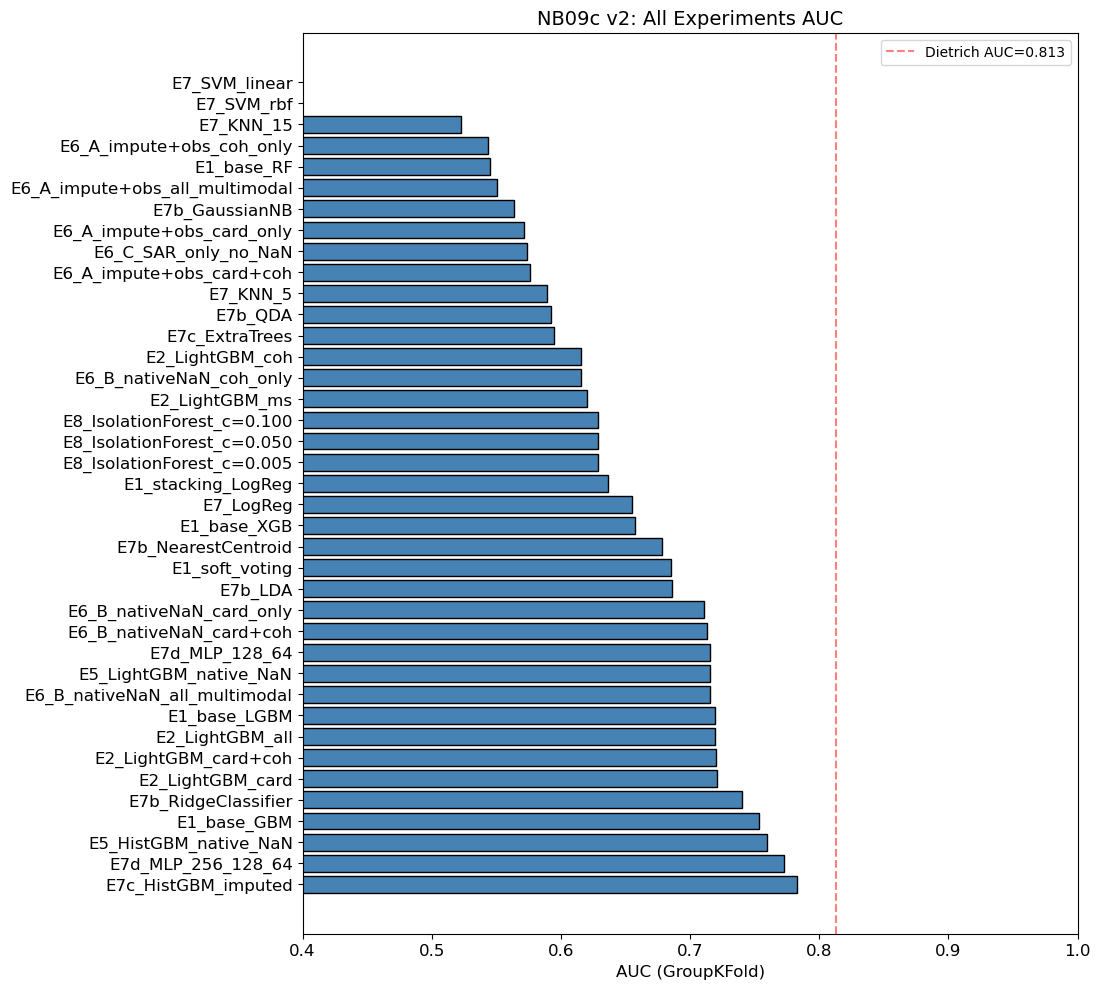

  Plot: cell_e9/comparison_bar_20260624_140243.png


In [22]:
# @title CELL E9: COMPARISON TABLE (all NB09c methods)
print("=" * 70)
print("CELL E9: NB09c COMPARISON TABLE")
print("=" * 70)

print(f"\n  {'Method':<50s} {'AUC':>7s} {'F1':>7s} {'N_feat':>7s}")
print(f"  {'-'*50} {'-'*7} {'-'*7} {'-'*7}")

for key in sorted(EXPERIMENT_LOG.keys()):
    res = EXPERIMENT_LOG[key]
    auc = res.get('auc', np.nan)
    f1 = res.get('f1', np.nan)
    nf = res.get('n_features', '?')
    auc_s = f"{auc:.3f}" if not np.isnan(auc) else "--"
    f1_s = f"{f1:.3f}" if not np.isnan(f1) else "--"
    print(f"  {key:<50s} {auc_s:>7s} {f1_s:>7s} {str(nf):>7s}")

print(f"\n  By category:")
for prefix, label in [('E1_', 'Stacking'), ('E2_', 'LightGBM'), ('E5_', 'Native NaN'),
                       ('E6_A', 'Impute+obs'), ('E6_B', 'NativeNaN'), ('E6_C', 'SAR-only'),
                       ('E7_', 'Non-tree'), ('E7b_', 'Discriminant'), ('E7c_', 'Tree-ext'),
                       ('E7d_', 'MLP'), ('E8_', 'IsolationForest')]:
    group = {k: v for k, v in EXPERIMENT_LOG.items() if k.startswith(prefix)}
    if group:
        best = max(group.items(), key=lambda x: x[1].get('auc', 0))
        print(f"    {label:20s}: best={best[0]} AUC={best[1].get('auc', 0):.3f}")

# save comparison table
comp_rows = []
for key in sorted(EXPERIMENT_LOG.keys()):
    res = EXPERIMENT_LOG[key]
    comp_rows.append({'method': key, 'auc': res.get('auc', np.nan), 'f1': res.get('f1', np.nan),
                      'n_features': res.get('n_features', 0), 'auc_std': res.get('auc_std', np.nan)})
if comp_rows:
    comp_df = pd.DataFrame(comp_rows).sort_values('auc', ascending=False)
    save_result(comp_df, 'comparison_table', 'cell_e9')

    fig, ax = plt.subplots(figsize=(10, max(4, len(comp_df) * 0.30)))
    ax.barh(comp_df['method'], comp_df['auc'].fillna(0), color='steelblue', edgecolor='black')
    ax.axvline(0.813, color='red', linestyle='--', alpha=0.5, label='Dietrich AUC=0.813')
    ax.set_xlabel('AUC (GroupKFold)')
    ax.set_xlim(0.4, 1.0)
    ax.set_title('NB09c v2: All Experiments AUC')
    ax.legend()
    save_fig(fig, 'comparison_bar', 'cell_e9')

# CELL E10: SAVE OOF PREDICTIONS + RESULTS

In [23]:
# @title CELL E10: SAVE OOF PREDICTIONS + RESULTS
import pickle

print("=" * 70)
print("CELL E10: SAVE RESULTS")
print("=" * 70)

# save experiment log (lightweight, no arrays)
results_clean = {}
for key, res in EXPERIMENT_LOG.items():
    results_clean[key] = {k: v for k, v in res.items()
                           if k not in ('y_true', 'y_proba', 'fold_aucs', 'groups')}
    results_clean[key]['auc'] = float(res.get('auc', 0))
    results_clean[key]['f1'] = float(res.get('f1', 0))

save_result(results_clean, 'experiment_log', 'cell_e10', fmt='json')

# save OOF predictions for NB10 stacking (legacy pickle kept for backward compat)
oof_data = {}
for key, res in EXPERIMENT_LOG.items():
    if 'y_true' in res and 'y_proba' in res:
        oof_data[key] = {
            'y_true': res['y_true'],
            'y_proba': res['y_proba'],
            'groups': res.get('groups'),
        }

with open(OUT_DIR / "nb09c_oof.pkl", 'wb') as f:
    pickle.dump(oof_data, f)
print(f"  OOF predictions (legacy pkl): {OUT_DIR / 'nb09c_oof.pkl'} ({len(oof_data)} experiments)")

# OOF inventory of canonical-schema parquets (written at callsites during the notebook run)
print(f"\n  OOF predictions inventory  ({OOF_DIR})")
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb09c_oof_inventory', 'cell_e10')
    print(f"  Total canonical OOF parquets: {len(oof_files)}")
else:
    print("  No canonical OOF parquets saved")

# summary CSV
summary_rows = []
for name, res in sorted(EXPERIMENT_LOG.items(), key=lambda x: -x[1].get('auc', 0)):
    summary_rows.append({'experiment': name, 'auc': res.get('auc', 0), 'f1': res.get('f1', 0),
                         'n_features': res.get('n_features', 0)})
if summary_rows:
    save_result(pd.DataFrame(summary_rows), 'experiment_summary', 'cell_e10')

try:
    registry.save()
except Exception as e:
    print(f"  registry.save() error: {e}")

print(f"  Experiments saved: {len(results_clean)}")

CELL E10: SAVE RESULTS
  Saved: cell_e10/experiment_log_20260624_140244.json (13.7 KB)
  OOF predictions (legacy pkl): /content/drive_f/masterthesis/results/nb09c_v2/nb09c_oof.pkl (39 experiments)

  OOF predictions inventory  (/content/drive_f/masterthesis/results/nb09c_v2/oof_predictions)
  Saved: cell_e10/nb09c_oof_inventory_20260624_140250.csv (8.9 KB)
  Total canonical OOF parquets: 61
  Saved: cell_e10/experiment_summary_20260624_140250.csv (2.3 KB)
  SAVED: NB09c_v2_experiments_20260614_180054.json (74 experiments)
  SAVED: NB09c_v2_experiments_20260614_180054.csv
  Experiments saved: 39
